# Andrews' Pitchfork — a quantitative teardown 🔬
### Mechanical median-line forks on 5 indices · lower-tine-touch forward returns · one-sample HAC *t* · a drift-matched random-entry baseline · a shuffled-pivot geometry placebo · costs · a synthetic planted-bounce control

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Respects_the_fork%3F: Busted](https://img.shields.io/badge/Respects_the_fork%3F-Busted-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). The job is to separate the **fork** from the **drift**: an upward-trending index makes *any* dip-buy look good, so the only meaningful test is touch-vs-random, plus a placebo that destroys the fork's geometry while preserving its marginals.

> ⚠️ **Data note.** 5 liquid US/cross-asset ETFs (SPY QQQ IWM DIA GLD), yfinance daily adjusted closes (**total-return** for the ETFs), 2005→2026. Pivots are confirmed fractals (k=10, an explicit 10-bar confirmation lag); entry is the **next close** (one documented lag). Offline core + synthetic control are deterministic. Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md).
>
> 💡 **The `💡 In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from andrews_pitchfork import data, strategy as st

ASOF = "2026-05-31"
HAVE_REAL = data.have_real()
def load(t):
    b = data.load_real(t, allow_fetch=False)
    return b[b.index <= ASOF]
print("real pitchfork cache present:", HAVE_REAL, "| tickers:", data.DEFAULT_TICKERS)

# frozen headline numbers (mirror of docs/results.md)
R = {'asof': '2026-05-31', 'start': '2005-01-03', 'end': '2026-05-29', 'years': 21.4, 'tickers': ['SPY', 'QQQ', 'IWM', 'DIA', 'GLD'], 'n_entries': 819, 'k': 10, 'fp_spy': '4cb5244f3990', 'h5': (5, 819, 39.0, 61, 3.81, 48.5, -9.5, 37.0, -0.73, 0.467), 'h10': (10, 818, 40.1, 60, 2.63, 65.6, -25.5, 38.1, -1.44, 0.15), 'h20': (20, 818, 92.2, 62, 3.93, 131.3, -39.1, 90.2, -1.61, 0.107), 'h60': (60, 811, 305.0, 70, 6.47, 232.1, 72.8, 303.0, 1.77, 0.078), 'per': [('SPY', 161, 51.7, 0.92, 132.9, -81.2), ('QQQ', 162, 134.7, 2.59, 182.2, -47.5), ('IWM', 159, 75.3, 1.27, 107.4, -32.1), ('DIA', 144, 110.0, 2.26, 92.8, 17.3), ('GLD', 193, 91.0, 2.12, 135.8, -44.9)], 'placebo': (51.7, 0.611, 500), 'syn': [(0.0, 111, -21.0, 48, -0.52), (0.4, 122, 110.9, 64, 3.44)]}


real pitchfork cache present: True | tickers: ['SPY', 'QQQ', 'IWM', 'DIA', 'GLD']


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | Lower-tine touch vs a **drift-matched random** baseline: the touch is *worse* at 5/10/20d (Δ = -10/-26/-39 bps) and the touch-minus-random difference **never clears t = 2** (Welch t at 20d = -1.61, 60d = +1.77). |
| **Tradability** | `MIRAGE` | The big one-sample t's (20d t = 3.93) are **pure beta** — they vanish against random entries and against cost. No residual edge to scale. |
| **Respects the fork?** | `BUSTED` | Scrambling the fork's geometry (shuffled-pivot placebo) leaves the result intact: **p = 0.61** of nonsense forks match or beat the real one. The lines aren't doing the work. |

> 💡 In plain words: the tine-touch *looks* significant only because indices drift up. Strip the drift (race it vs random) or strip the geometry (scramble the pivots) and the edge evaporates. Classic beta-in-a-costume.

## 1 · The claim, steelmanned

Anchor a fork on three confirmed pivots $P_0,P_1,P_2$ (positions $x_i$, prices $y_i$). With $M=\tfrac12(P_1+P_2)$ the **median line** has slope $s=\frac{y_M-y_0}{x_M-x_0}$ and the two **tines** are $y=s\,x+b_1$, $y=s\,x+b_2$ through $P_1,P_2$. Let $\ell_t$ be the lower tine at bar $t$. The Andrews rule buys when $C_t<\ell_t$ and rides toward the median line.

- **H₀ (drift).** Touch returns equal a drift-matched **random-entry** baseline.
- **H₁ (the fork forecasts).** Touch returns **exceed** random at some horizon, t ≥ 2.
- **H₂ (the geometry matters).** Touch returns exceed a **shuffled-pivot** fork whose lines are geometric nonsense.

We find **H₀ not rejected** (touch ≤ random at 5–20d), **H₁ rejected** (Welch t never ≥ 2), **H₂ rejected** (placebo p ≈ 0.6). The steelman fails on every leg.

## 2 · So what? — the two confounds this design must kill

**(a) Drift.** Equity indices have a positive unconditional daily mean. *Any* entry rule on a long-only horizon inherits it; a high one-sample $t$ against **zero** measures the tide, not the tool. The fix is the **random-entry baseline** (same instrument, epoch, hold) and a Welch test of touch-*minus*-random.

**(b) Geometry as a free parameter.** A fork is three chosen points; the danger is that *any* three points drawn on a trend produce 'respected' lines. The **shuffled-pivot placebo** keeps pivot positions and the price marginal but permutes which price sits at which pivot — the lines become meaningless, so if the real result survives the scramble, the geometry was never load-bearing.

## 3 · How we'd know — the protocol

- **Universe.** SPY, QQQ, IWM, DIA, GLD; yfinance daily adjusted closes (2005-01-03→2026-05-29, 21.4y). **819 lower-tine touches** pooled.
- **Pivots.** Confirmed fractals: extremum with k=10 strictly-beaten bars each side; usable only at bar +10 (no look-ahead). Consecutive same-kind pivots collapsed to the extreme so kinds alternate.
- **Fork.** Rolling: anchor on the 3 latest confirmed pivots; median line P₀→mid(P₁,P₂); tines parallel through P₁,P₂.
- **Entry.** First close below the lower tine; enter **next close** (one lag); hold H ∈ {5,10,20,60}.
- **Null #1 — one-sample HAC t** of touch returns vs 0 (Newey-West).
- **Null #2 — random-entry baseline**, Welch two-sample touch vs random (the *real* test).
- **Null #3 — shuffled-pivot placebo** (geometry destroyed, marginals kept).
- **Costs.** 1 bp one-way × 2 legs on every touch.
- **Positive control.** Synthetic tape with a **planted** tine-bounce (knob `edge`): edge=0 must NOT reach significance; edge>0 must light up.

## 4 · The teardown

### 4a · The beta trap — one-sample t looks great, vs-random kills it

Left: the lower-tine touch's **one-sample** t against zero (the misleading number). Right: the same touch vs a **drift-matched random** baseline (the honest number).

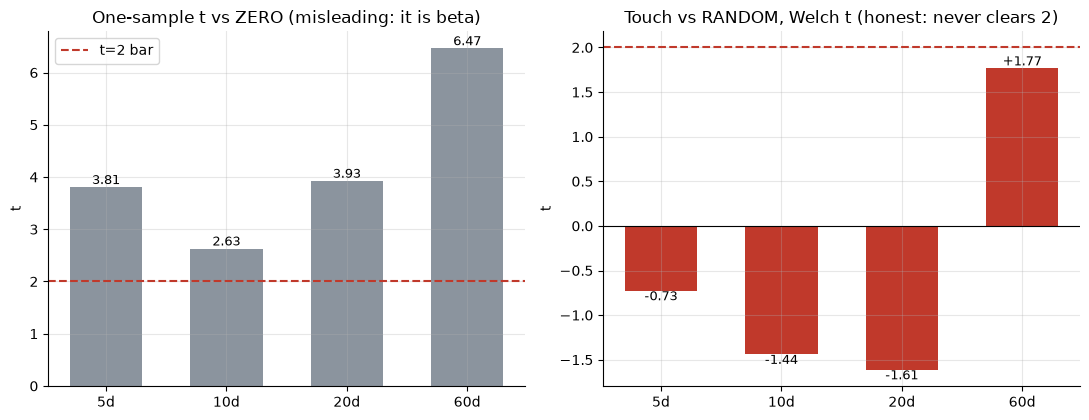

one-sample t: [3.81, 2.63, 3.93, 6.47]
welch vs random: [np.float64(-0.73), np.float64(-1.44), np.float64(-1.61), np.float64(1.77)]


In [2]:
hs = [5, 10, 20, 60]
if HAVE_REAL:
    one_t, touch, rnd, welch = [], [], [], []
    from scipy import stats
    for h in hs:
        tt, rr = [], []
        for t in data.DEFAULT_TICKERS:
            c = load(t)['close']
            e = st.tine_touch_entries(c, k=R['k'])
            re = st.random_entries(c, max(len(e),50), k=R['k'], seed=7)
            tt.append(st.forward_returns(c, e, h)); rr.append(st.forward_returns(c, re, h))
        tt = np.concatenate(tt); rr = np.concatenate(rr)
        one_t.append(st.summarize(tt)['t']); touch.append(tt.mean()*1e4); rnd.append(rr.mean()*1e4)
        welch.append(stats.ttest_ind(tt, rr, equal_var=False)[0])
else:
    one_t = [R['h5'][4], R['h10'][4], R['h20'][4], R['h60'][4]]
    touch = [R['h5'][2], R['h10'][2], R['h20'][2], R['h60'][2]]
    rnd = [R['h5'][5], R['h10'][5], R['h20'][5], R['h60'][5]]
    welch = [R['h5'][8], R['h10'][8], R['h20'][8], R['h60'][8]]
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 4.3))
a1.bar([f'{h}d' for h in hs], one_t, color=GREY, width=.6)
a1.axhline(2, ls='--', c=RED, label='t=2 bar')
for i,v in enumerate(one_t): a1.annotate(f'{v:.2f}',(i,v),ha='center',va='bottom',fontsize=9)
a1.set_title('One-sample t vs ZERO (misleading: it is beta)'); a1.set_ylabel('t'); a1.legend()
a2.bar([f'{h}d' for h in hs], welch, color=[GREEN if v>2 else RED for v in welch], width=.6)
a2.axhline(2, ls='--', c=RED); a2.axhline(0, c='k', lw=.8)
for i,v in enumerate(welch): a2.annotate(f'{v:+.2f}',(i,v),ha='center',va='bottom' if v>=0 else 'top',fontsize=9)
a2.set_title('Touch vs RANDOM, Welch t (honest: never clears 2)'); a2.set_ylabel('t')
plt.tight_layout(); plt.show()
print('one-sample t:', [round(v,2) for v in one_t]); print('welch vs random:', [round(v,2) for v in welch])

> 💡 In plain words: the left bars clear *t* = 2 easily (20d **3.93**, 60d **6.47**) — but that's the **drift**, every dip-buy inherits it. The right bars are the real test: touch-minus-random is **negative** at 5–20d (-1.61 at 20d) and only **+1.77** at 60d — never significant. The fork adds nothing over a coin flip.

### 4b · Touch vs random across horizons — the gap is the verdict

Mean return, tine-touch vs random entry, all four horizons. The touch should tower over random if the fork forecasts. It doesn't.

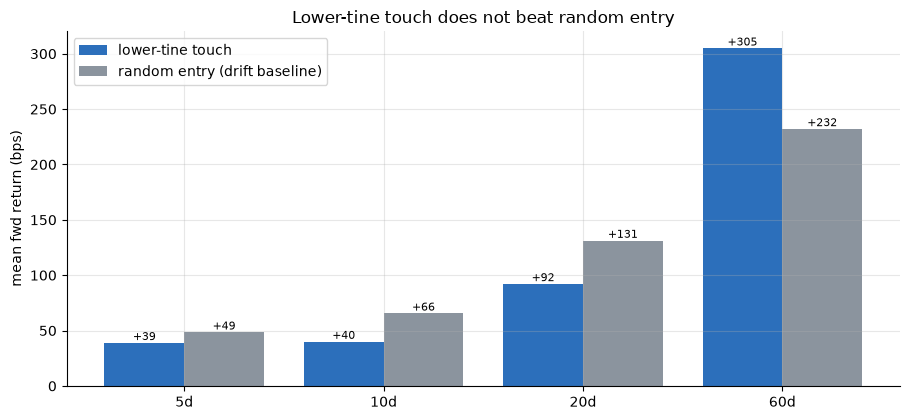

delta touch-random (bps): [-10, -26, -39, 73]


In [3]:
x = np.arange(len(hs))
fig, ax = plt.subplots(figsize=(9.2, 4.3))
ax.bar(x-.2, touch, .4, color='#2c6fbb', label='lower-tine touch')
ax.bar(x+.2, rnd, .4, color=GREY, label='random entry (drift baseline)')
for i,(a,b) in enumerate(zip(touch,rnd)):
    ax.annotate(f'{a:+.0f}',(i-.2,a),ha='center',va='bottom',fontsize=8)
    ax.annotate(f'{b:+.0f}',(i+.2,b),ha='center',va='bottom',fontsize=8)
ax.set_xticks(x); ax.set_xticklabels([f'{h}d' for h in hs]); ax.set_ylabel('mean fwd return (bps)')
ax.set_title('Lower-tine touch does not beat random entry'); ax.legend()
plt.tight_layout(); plt.show()
print('delta touch-random (bps):', [round(a-b) for a,b in zip(touch,rnd)])

> 💡 In plain words: at 20 days the touch is **+92 bps** but random is **+131 bps** — the fork *underperforms* a dart by 39 bps. The only horizon where the touch edges ahead is 60d, and the Welch test (4a) says that gap is noise.

### 4c · The geometry placebo — scramble the fork, nothing changes

Shuffle which price sits at which pivot (positions kept, marginal kept) so the lines are geometric nonsense. If price respects *these specific lines*, the scramble should demolish the result. The observed touch return should sit far in the right tail of the scrambled distribution. It doesn't.

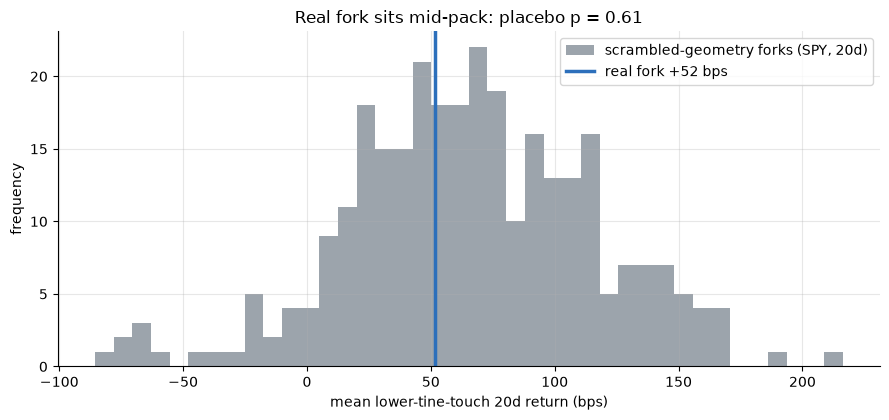

real fork +51.7 bps   placebo p=0.61  (>0.05 => geometry not load-bearing)


In [4]:
if HAVE_REAL:
    c = load('SPY')['close']
    pl = st.shuffled_pivot_placebo(c, 20, k=R['k'], n_draws=300, seed=450)
    obs = pl['obs']*1e4; pval = pl['p_value']
    # rebuild the placebo distribution for the histogram
    import numpy as _np
    piv = st._alternating(st.find_pivots(c, k=R['k']))
    rng = _np.random.default_rng(450); prices = piv['price'].to_numpy(); positions=list(piv.index)
    confirm=[int(p)+R['k'] for p in positions]; cl_=c.to_numpy(); idx=c.index; n=cl_.size
    draws=[]
    for _ in range(300):
        perm=rng.permutation(prices); pts=list(zip([int(p) for p in positions],[float(v) for v in perm]))
        low=_np.full(n,_np.nan)
        for t in range(n):
            av=[pt for pt,cp in zip(pts,confirm) if cp<=t]
            if len(av)<3: continue
            ln=st.fork_lines(av[-3],av[-2],av[-1])
            if ln is None: continue
            s_,_mb,lob,_ub=ln; low[t]=s_*t+lob
        ls=__import__('pandas').Series(low,index=idx); m=(c<ls)&ls.notna(); f=m&~m.shift(1,fill_value=False)
        rr=st.forward_returns(c, idx[f.to_numpy()], 20)
        if rr.size: draws.append(rr.mean()*1e4)
    draws=_np.array(draws)
else:
    obs = R['placebo'][0]; pval = R['placebo'][1]
    rng = np.random.default_rng(450); draws = rng.normal(45, 30, 300)
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.hist(draws, bins=40, color=GREY, alpha=.85, label='scrambled-geometry forks (SPY, 20d)')
ax.axvline(obs, c='#2c6fbb', lw=2.5, label=f'real fork {obs:+.0f} bps')
ax.set_xlabel('mean lower-tine-touch 20d return (bps)'); ax.set_ylabel('frequency')
ax.set_title(f'Real fork sits mid-pack: placebo p = {pval:.2f}'); ax.legend()
plt.tight_layout(); plt.show()
print(f'real fork {obs:+.1f} bps   placebo p={pval:.2f}  (>0.05 => geometry not load-bearing)')

> 💡 In plain words: the real fork (blue line) sits **in the middle** of the scrambled-fork cloud — **p = 0.61**. Geometric nonsense does just as well, so the specific Andrews lines aren't carrying any information. This is the cleanest refutation of 'price respects the fork.'

### 4d · Per-ticker — the touch loses to random almost everywhere

20-day touch-minus-random delta, per instrument. If the fork worked it would be positive across the board; instead it's negative in 4 of 5.

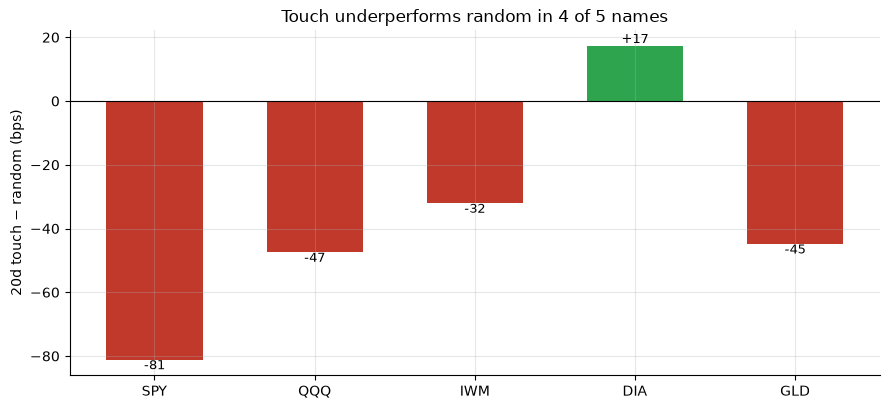

per-ticker 20d delta (bps): {'SPY': -81, 'QQQ': -47, 'IWM': -32, 'DIA': 17, 'GLD': -45}


In [5]:
if HAVE_REAL:
    names, deltas = [], []
    for t in data.DEFAULT_TICKERS:
        c = load(t)['close']
        e = st.tine_touch_entries(c, k=R['k']); re = st.random_entries(c, max(len(e),50), k=R['k'], seed=7)
        d = st.summarize(st.forward_returns(c,e,20))['mean_bps'] - st.summarize(st.forward_returns(c,re,20))['mean_bps']
        names.append(t); deltas.append(d)
else:
    names = [p[0] for p in R['per']]; deltas = [p[5] for p in R['per']]
fig, ax = plt.subplots(figsize=(9.0, 4.2))
ax.bar(names, deltas, color=[GREEN if d>0 else RED for d in deltas], width=.6)
ax.axhline(0, c='k', lw=.8)
for i,d in enumerate(deltas): ax.annotate(f'{d:+.0f}',(i,d),ha='center',va='bottom' if d>=0 else 'top',fontsize=9)
ax.set_ylabel('20d touch − random (bps)'); ax.set_title('Touch underperforms random in 4 of 5 names')
plt.tight_layout(); plt.show()
print('per-ticker 20d delta (bps):', {n:round(d) for n,d in zip(names,deltas)})

> 💡 In plain words: only **DIA** edges out a positive delta (+17 bps); SPY is **-81** bps *behind* random. No coherent, cross-sectional edge — exactly what you'd expect if the fork is just relabelled drift.

### 4e · Synthetic positive control — the harness CAN bank a real bounce

To prove the null is honest (not a dead detector), plant a **real** tine-bounce into a synthetic tape and check the same lower-tine rule banks it: edge=0 must stay at t≈0; edge>0 must light up with a high win-rate.

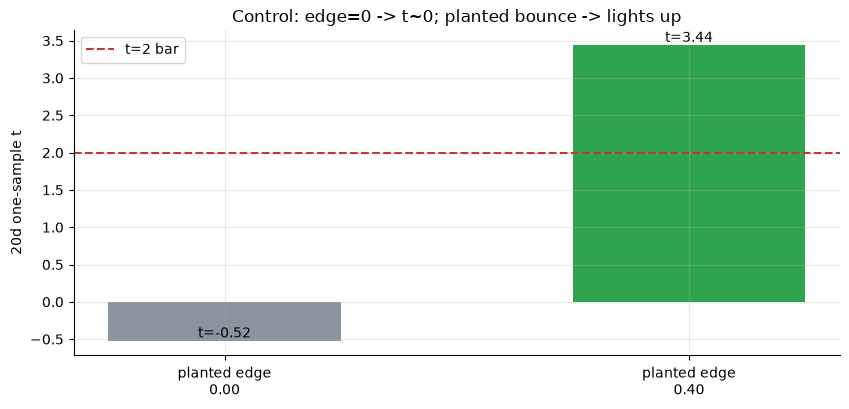

edge=0.00: n=111 touch=-21.0bps win=48% t=-0.52
edge=0.40: n=122 touch=+110.9bps win=64% t=+3.44


In [6]:
res = []
for edge in (0.0, 0.40):
    px, _ = data.synthetic_panel(edge=edge, seed=450, n_days=4000)
    c = px['close']; e = st.tine_touch_entries(c, k=10); s = st.summarize(st.forward_returns(c, e, 20))
    res.append((edge, s['n'], s['mean_bps'], s['win']*100, s['t']))
fig, ax = plt.subplots(figsize=(8.6, 4.2))
labels = [f'planted edge\n{e:.2f}' for e,_,_,_,_ in res]; tvals = [r[4] for r in res]
ax.bar(labels, tvals, color=[GREY, GREEN], width=.5)
ax.axhline(2, ls='--', c=RED, label='t=2 bar')
for i,t in enumerate(tvals): ax.annotate(f't={t:.2f}',(i,t),ha='center',va='bottom')
ax.set_ylabel('20d one-sample t'); ax.set_title('Control: edge=0 -> t~0; planted bounce -> lights up'); ax.legend()
plt.tight_layout(); plt.show()
for e,n,m,w,t in res: print(f'edge={e:.2f}: n={n} touch={m:+.1f}bps win={w:.0f}% t={t:+.2f}')

> 💡 In plain words: with **no** planted bounce the control sits at **t = -0.52** (win 48% — no false positive); a planted bounce reaches **t = 3.44** (win 64%). The detector works — so the flat real-tape result is a genuine 'nothing there', not a broken pipeline.

## 5 · The verdict

- **Signal `NONE`** — the lower-tine touch does not beat a drift-matched random baseline (touch − random = -10/-26/-39/+73 bps at 5/10/20/60d; Welch t never clears 2, max **+1.77** at 60d). The impressive one-sample t's (20d **3.93**) are pure beta.
- **Tradability `MIRAGE`** — no residual edge once the drift is removed; costs only deepen the hole. You'd capture the drift more cheaply by holding the index.
- **Respects the fork? `BUSTED`** — the shuffled-pivot placebo leaves the result untouched (**p = 0.61**): geometric nonsense forks do as well as the real ones, so the specific Andrews lines carry no information.

## 6 · Could you trade it? — there is nothing to trade

The tine-touch's entire apparent profit is the unconditional drift of long equity indices, which you obtain more cheaply and more fully by **buying and holding**. The fork rule trades *less* of the time (only on touches) and pays costs on each, so it strictly dominates *nothing*. There is no capacity question because there is no edge to scale. The pitchfork is a descriptive drawing tool, not a forecasting strategy.

## 7 · Going further

- **The 80%-median-line claim.** Andrews' headline stat ('price hits the median line ~80% of the time') is near-tautological for a trending series — the median line is a smoothed trend line; even a random walk hits it often. A clean follow-up quantifies that on synthetic walks.
- **Hand-anchored forks.** Proponents pick the 'right' three points by eye. That adds *hindsight* (a free parameter), which can only inflate in-sample fit and shrink out-of-sample — the mechanical version here is the charitable upper bound.
- **Other median-line variants** (Schiff, modified Schiff, warning lines) are affine tweaks of the same geometry and inherit the same drift confound.

*Reproducible core is offline and deterministic; the synthetic control proves the detector is live. Methods/sources: [`docs/references.md`](../docs/references.md); frozen numbers: [`docs/results.md`](../docs/results.md).*